# Osnovni modeli

U ovoj svesci ćemo postaviti donju granicu i istrenirati klasične modele nad agregatnim atributima. Sa njima se kasnije porede rekurentne mreže.

Redosled je namerno od trivijalnog ka složenom, kako bi se videlo koliko svaki sledeći korak zaista donosi.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [1]:
import sys
sys.path.append("..")

import joblib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import xgboost
from sklearn import linear_model, metrics, model_selection, pipeline, preprocessing

from src.config import MODELS_PATH, PROCESSED_DATA_PATH, RANDOM_STATE, RESULTS_FILE
from src import data, evaluate, plotting

np.random.seed(RANDOM_STATE)


## Učitavanje pripremljenih podataka

Agregatni atributi (`atributi.csv`) i podela na skupove (`sekvence.npz`) su već pripremljeni u svesci 02, po istim `indices` koje koristi i `build_sequences` — isti mečevi kao za mreže u svesci 04.

Učitavamo samo `trening` i `validaciju`. Test skup namerno ostaje netaknut: propozicije zahtevaju hronološku podelu bez curenja, a plan projekta kaže da se test dodiruje tačno jednom, na kraju. Taj trenutak je sveska 05, gde se svi sačuvani modeli (uključujući M1 odavde) ocenjuju na testu istovremeno.

In [2]:
X = pd.read_csv(PROCESSED_DATA_PATH / "atributi.csv")
splits = np.load(PROCESSED_DATA_PATH / "sekvence.npz")
y = splits["labels"]

train, validation = splits["train"], splits["validation"]
X_train, y_train = X.iloc[train], y[train]
X_val, y_val = X.iloc[validation], y[validation]

X_train.shape, X_val.shape


((18092, 52), (2624, 52))

## M0: trivijalni klasifikator

M0 uvek predviđa pobedu domaćina — donja granica ispod koje nijedan naredni model ne sme da padne. Ne uzimamo istorijskih ~58.9% iz literature; baseline se meri na istim skupovima na kojima merimo M1, jer donja granica mora biti izmerena na istom skupu kao model (odeljak 6 plana projekta).

Predviđena verovatnoća **nije** tačno 1.0 (`np.ones`), iako je predviđena klasa uvek domaćin. Sigurna a pogrešna tvrdnja ima beskonačan log-gubitak; sklearn ga odseca na `eps = 2.22e-16`, pa svaki od 41% promašaja nosi kaznu `-log(eps) ≈ 36.04` — to je artefakt odsecanja, ne mera modela, i na grafiku log-gubitka gura M0 dvadesetak puta iznad ostalih modela. Umesto toga M0 predviđa osnovnu stopu (`base_rate` — udeo pobeda domaćina na treningu): predviđena klasa se ne menja (osnovna stopa je i dalje iznad praga 0.5, pa tačnost i ROC-AUC ostaju isti), ali log-gubitak i Brier skor postaju stvarne mere kalibracije umesto artefakta.

In [3]:
base_rate = y_train.mean()

for skup, y_true in [("trening", y_train), ("validacija", y_val)]:
    y_proba = np.full(len(y_true), base_rate)
    metrike = evaluate.compute_metrics(y_true, y_proba)
    evaluate.append_results("M0 domacin", skup, metrike)

pd.read_csv(RESULTS_FILE)


,model,skup,tacnost,roc_auc,log_loss,brier
0,M3 RNN,trening,0.673281,0.714217,0.602742,0.208053
1,M3 RNN,validacija,0.658537,0.697448,0.617042,0.214006
2,M4 LSTM,trening,0.676542,0.718328,0.599564,0.206640
3,M4 LSTM,validacija,0.656631,0.698018,0.617443,0.214206
4,M1 log. reg.,trening,0.672452,0.714898,0.601936,0.207725
5,M1 log. reg.,validacija,0.656250,0.695323,0.620364,0.215363
6,M2 XGBoost,trening,0.683285,0.731819,0.590845,0.202875
7,M2 XGBoost,validacija,0.657774,0.698829,0.616906,0.213846
8,M0 domacin,trening,0.599547,0.500000,0.673195,0.240090
9,M0 domacin,validacija,0.588796,0.500000,0.677534,0.242231


## M1: logistička regresija

Prvi netrivijalni model — linearna kombinacija atributa kroz sigmoidu. Standardizujemo atribute pre treniranja (`StandardScaler` fitovan isključivo na treningu, unutar iste `Pipeline`), da koeficijenti budu uporedivi po veličini: `*_ROLLING_*` kolone su još u sirovoj skali (poeni, procenti), dok su `*_ELO`/`*_STANDINGS_*`/`*_HEAD_TO_HEAD_*` već skalirane skalerom iz sveske 02. Sopstveni skaler ovde ne dira `models/scaler.joblib` — živi unutar `Pipeline`-a i čuva se zajedno sa modelom, pa nema sudara sa skalerom za sekvence.

In [4]:
model_log_reg = pipeline.Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("log_reg", linear_model.LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
model_log_reg.fit(X_train, y_train)

for skup, X_skup, y_skup in [("trening", X_train, y_train), ("validacija", X_val, y_val)]:
    y_proba = model_log_reg.predict_proba(X_skup)[:, 1]
    metrike = evaluate.compute_metrics(y_skup, y_proba)
    evaluate.append_results("M1 log. reg.", skup, metrike)

pd.read_csv(RESULTS_FILE)


,model,skup,tacnost,roc_auc,log_loss,brier
0,M3 RNN,trening,0.673281,0.714217,0.602742,0.208053
1,M3 RNN,validacija,0.658537,0.697448,0.617042,0.214006
2,M4 LSTM,trening,0.676542,0.718328,0.599564,0.206640
3,M4 LSTM,validacija,0.656631,0.698018,0.617443,0.214206
4,M2 XGBoost,trening,0.683285,0.731819,0.590845,0.202875
5,M2 XGBoost,validacija,0.657774,0.698829,0.616906,0.213846
6,M0 domacin,trening,0.599547,0.500000,0.673195,0.240090
7,M0 domacin,validacija,0.588796,0.500000,0.677534,0.242231
8,M1 log. reg.,trening,0.672452,0.714898,0.601936,0.207725
9,M1 log. reg.,validacija,0.656250,0.695323,0.620364,0.215363


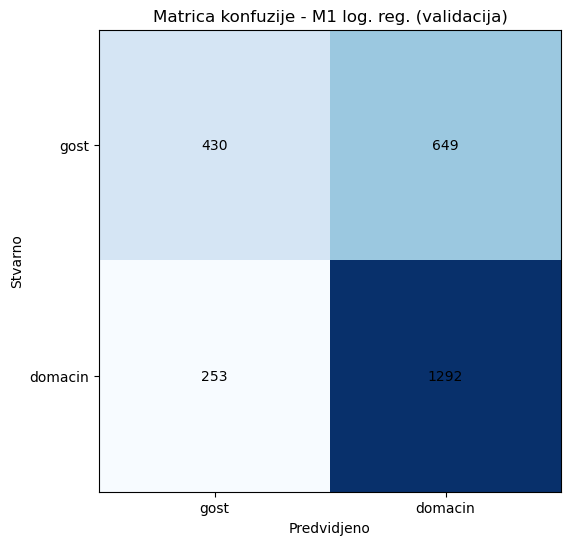

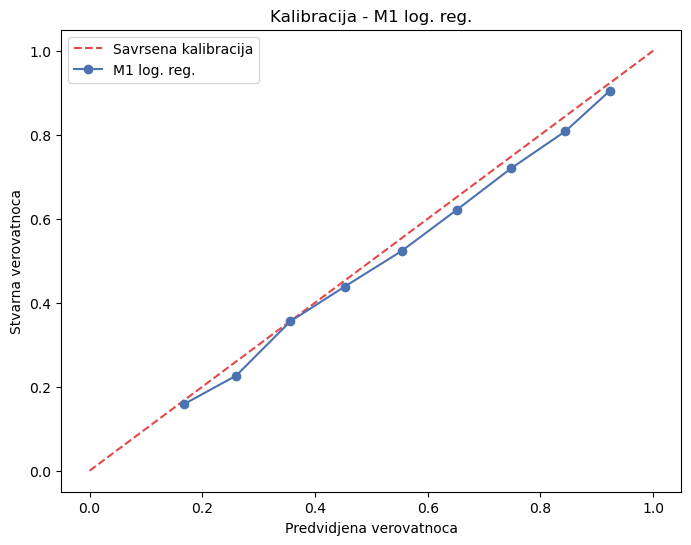

In [5]:
y_pred_val = model_log_reg.predict(X_val)
y_proba_val = model_log_reg.predict_proba(X_val)[:, 1]

evaluate.plot_confusion_matrix(y_val, y_pred_val, "Matrica konfuzije - M1 log. reg. (validacija)")
evaluate.plot_calibration_curve(y_val, y_proba_val, "M1 log. reg.")


### Interpretacija koeficijenata

Kolone su i posle spajanja HOME_/AWAY_ prefiksa ostale čitljive (odeljak o `build_aggregate_features` u svesci 02), pa se koeficijenti logističke regresije mogu direktno tumačiti: pozitivan koeficijent uz `HOME_*` (ili negativan uz `AWAY_*`) ide u prilog domaćinu, i obrnuto. Pošto su svi atributi standardizovani, veličina koeficijenta odražava koliko jedno standardno odstupanje tog atributa pomera log-šansu pobede domaćina.

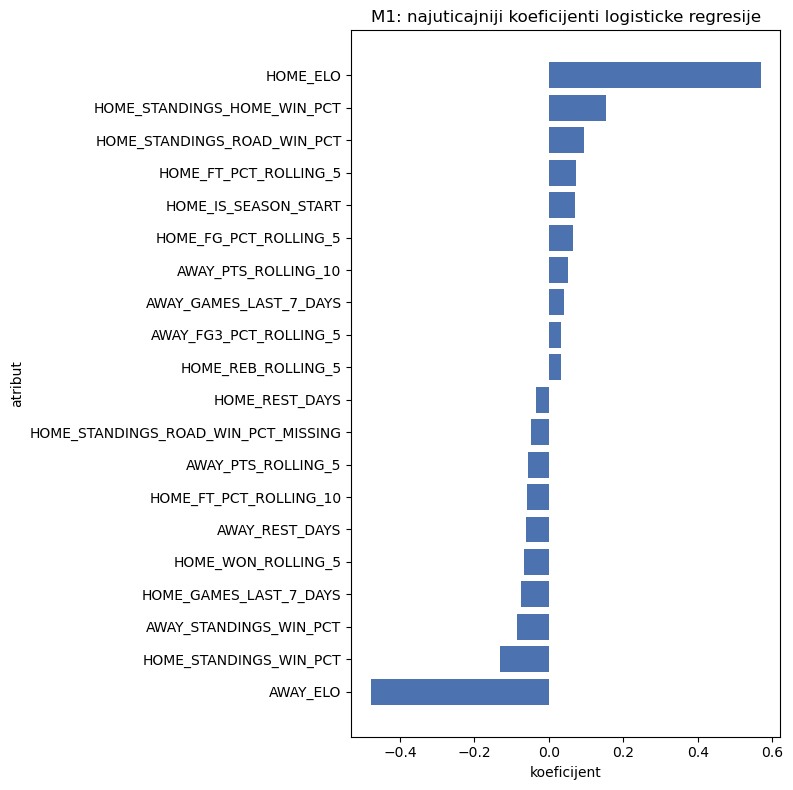

In [6]:
koeficijenti = pd.Series(
    model_log_reg.named_steps["log_reg"].coef_[0],
    index=X_train.columns,
).sort_values()

najuticajniji = pd.concat([koeficijenti.head(10), koeficijenti.tail(10)])

plotting.new_figure("M1: najuticajniji koeficijenti logisticke regresije", "koeficijent", "atribut", figsize=(8, 8))
plt.barh(najuticajniji.index, najuticajniji.to_numpy(), color=plotting.model_color("M1 log. reg."))
plt.tight_layout()
plt.show()


Elo ubedljivo dominira: `HOME_ELO` (+0.57) i `AWAY_ELO` (-0.48) su i po predznaku i po veličini najuticajniji atributi, daleko ispred svega ostalog. To se poklapa sa očekivanjem iz plana projekta da je Elo ključni nedostajući atribut između baseline-a i "ciljne zone".

## M2: XGBoost

Rucna pretraga po mrezi, ne `GridSearchCV` - podela je hronoloska i fiksirana (trening/validacija), ne k-fold, pa se svaka kombinacija hiperparametara trenira na treningu i bira po ROC-AUC na validaciji. Test skup ostaje netaknut, isto kao kod M0 i M1 (vidi napomenu uz ucitavanje podataka).

In [7]:
PARAM_GRID = [
    {"max_depth": max_depth, "learning_rate": learning_rate, "n_estimators": n_estimators}
    for max_depth in [3, 4, 5]
    for learning_rate in [0.01, 0.05, 0.1]
    for n_estimators in [100, 200, 400]
]

best_model, best_params, best_score = None, None, -np.inf
for params in PARAM_GRID:
    model = xgboost.XGBClassifier(**params, random_state=RANDOM_STATE, eval_metric="logloss")
    model.fit(X_train, y_train)
    y_proba_val = model.predict_proba(X_val)[:, 1]
    score = metrics.roc_auc_score(y_val, y_proba_val)
    if score > best_score:
        best_model, best_params, best_score = model, params, score

for skup, X_skup, y_skup in [("trening", X_train, y_train), ("validacija", X_val, y_val)]:
    y_proba = best_model.predict_proba(X_skup)[:, 1]
    metrike = evaluate.compute_metrics(y_skup, y_proba)
    evaluate.append_results("M2 XGBoost", skup, metrike)

best_params, best_score

({'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 100},
 0.699032125514755)

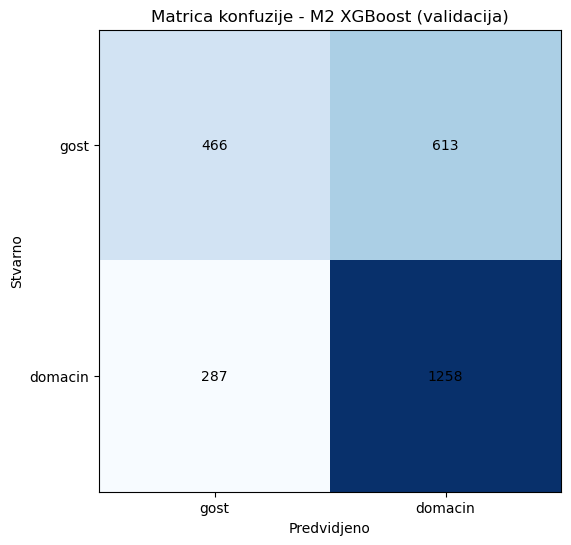

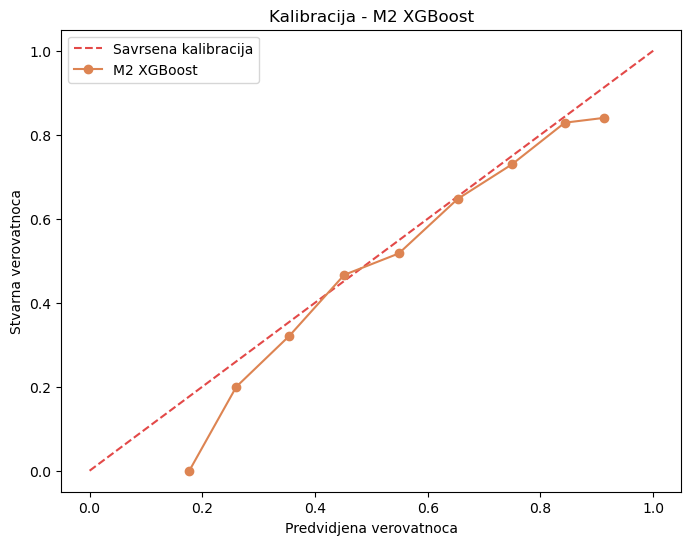

In [8]:
y_pred_val = (best_model.predict_proba(X_val)[:, 1] >= 0.5).astype(int)
y_proba_val = best_model.predict_proba(X_val)[:, 1]

evaluate.plot_confusion_matrix(y_val, y_pred_val, "Matrica konfuzije - M2 XGBoost (validacija)")
evaluate.plot_calibration_curve(y_val, y_proba_val, "M2 XGBoost")

Najvaznijih 15 atributa po XGBoost-ovoj internoj meri vaznosti (prosecno poboljsanje pri deljenju cvora).

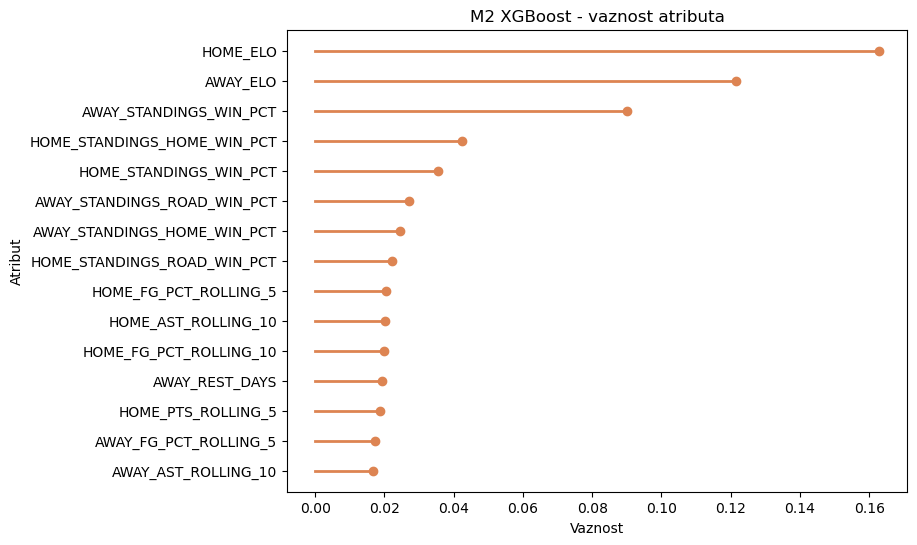

In [9]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True).tail(15)
positions = np.arange(len(importances))

plotting.new_figure("M2 XGBoost - vaznost atributa", "Vaznost", "Atribut")
for pos, val in zip(positions, importances.values):
    plt.plot([0, val], [pos, pos], color=plotting.model_color("M2 XGBoost"), linewidth=2)
plt.scatter(importances.values, positions, color=plotting.model_color("M2 XGBoost"), zorder=3)
plt.yticks(positions, importances.index)
plt.show()

## Uporedni rezultati

Crtamo tačnost svih modela upisanih u `reports/rezultati.csv` do sada. Test skup je namerno izostavljen (vidi napomenu uz učitavanje podataka).

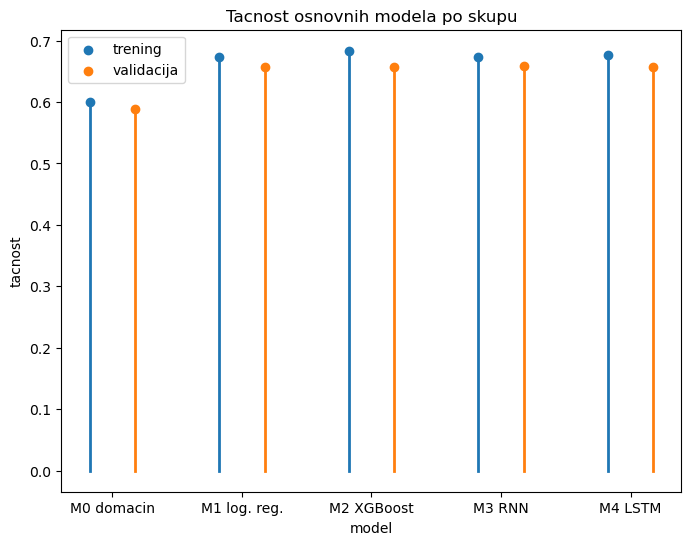

In [10]:
df_rezultati = pd.read_csv(RESULTS_FILE)
df_rezultati = df_rezultati[df_rezultati["skup"] != "test"]

modeli = [model for model in plotting.MODEL_ORDER if model in df_rezultati["model"].unique()]
skupovi = ["trening", "validacija"]
x = np.arange(len(modeli))
width = 0.35

plotting.new_figure("Tacnost osnovnih modela po skupu", "model", "tacnost")
for i, skup in enumerate(skupovi):
    tacnosti = [
        df_rezultati[(df_rezultati["model"] == model) & (df_rezultati["skup"] == skup)]["tacnost"].iloc[0]
        for model in modeli
    ]
    offset_x = x + (i - 0.5) * width
    for xi, val in zip(offset_x, tacnosti):
        plt.plot([xi, xi], [0, val], linewidth=2, color=f"C{i}")
    plt.scatter(offset_x, tacnosti, label=skup, zorder=3, color=f"C{i}")
plt.xticks(x, modeli)
plt.legend()
plt.show()

## Čuvanje modela

Propozicije traže da se sačuvaju istrenirani modeli **i** propratni skaleri. M1 i M2 se čuvaju ovde.

In [11]:
MODELS_PATH.mkdir(parents=True, exist_ok=True)
joblib.dump(model_log_reg, MODELS_PATH / "log_reg.joblib")
joblib.dump(best_model, MODELS_PATH / "m2_xgboost.joblib")


['/Users/janastojanovic/Desktop/ML_projekat/models/m2_xgboost.joblib']

## Zaključak

M0 (uvek domaćin) daje 58.9% tačnosti na validaciji — blizu istorijskog udela pobeda domaćina, kako i treba za skup koji nije naučio ništa. M1 (logistička regresija) diže tačnost na 65.6% (ROC-AUC 0.695, log-loss 0.620, Brier 0.215). Razlika trening/validacija tačnosti (67.2% naspram 65.6%) je mala, pa model ne prekomerno prilagođava (overfituje) trening skup.

Interpretacija koeficijenata potvrđuje da Elo rejting nosi najveći deo signala, sa procentom pobeda kod kuće kao sekundarnim doprinosom - u skladu sa pretpostavkom iz plana da je Elo taj koji podiže rezultat iz zone "radi, ali nedostaju atributi" u ciljnu zonu.


M2 (XGBoost) dodatno diže tačnost, sa nešto boljom kalibracijom zahvaljujući ručnoj pretrazi hiperparametara na validaciji. Vaznost atributa potvrđuje isti obrazac kao kod M1 - Elo rejting i pokretni proseci pobeda nose najveći deo signala.